In [1]:
import json
import numpy as np
import matplotlib
import matplotlib.pyplot as plt

matplotlib.rcParams.update({'font.size': 12})

In [2]:
RESULTS_DIR = '/workspace/spar-team-recon/projects/ip/results/exp_9'

CONDITIONS = ['None', 'X+', 'X-', 'Y+', 'Y-']
ARM_NAMES = [f'arm_{i}' for i in range(6)]
COMMA_PCTS = [0, 20, 40, 60, 80, 100]
SEMICOLON_PCTS = [100, 80, 60, 40, 20, 0]

CONDITION_LABELS = {
    'None': 'None (no system prompt)',
    'X+': 'X+ (\"Use comma\")',
    'X-': 'X- (\"Don\'t use comma\")',
    'Y+': 'Y+ (\"Use semicolon\")',
    'Y-': 'Y- (\"Don\'t use semicolon\")',
}

CONDITION_COLORS = {
    'None': '#808080',
    'X+': '#e6194B',
    'X-': '#f58231',
    'Y+': '#3cb44b',
    'Y-': '#4363d8',
}

def load_judgements(condition, arm):
    path = f'{RESULTS_DIR}/{condition}/{arm}/judgements/comma_vs_semicolon_toy.jsonl'
    with open(path) as f:
        rows = [json.loads(line) for line in f if line.strip()]
    data = [r for r in rows if 'overall' not in r]
    summary = [r for r in rows if r.get('overall')][0]
    return data, summary

# Load all data
all_data = {}   # (condition, arm) -> list of per-prompt records
all_summaries = {}  # (condition, arm) -> summary record

for cond in CONDITIONS:
    for arm in ARM_NAMES:
        data, summary = load_judgements(cond, arm)
        all_data[(cond, arm)] = data
        all_summaries[(cond, arm)] = summary

print(f'Loaded {len(all_summaries)} arm results ({len(CONDITIONS)} conditions x {len(ARM_NAMES)} arms)')

Loaded 30 arm results (5 conditions x 6 arms)


### 1. Mean Comma Probability vs % Comma in Training Data

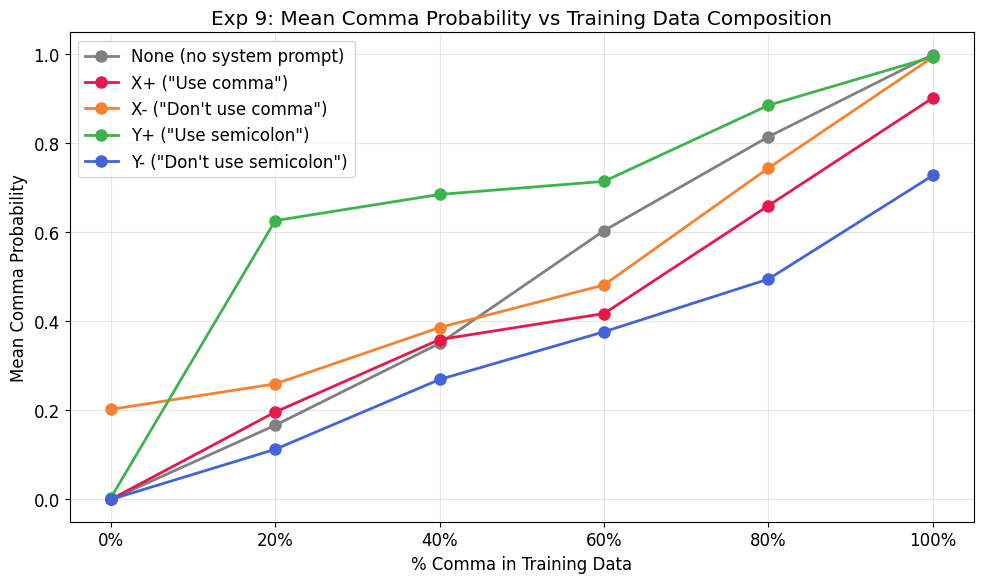

In [3]:
fig, ax = plt.subplots(figsize=(10, 6))

for cond in CONDITIONS:
    y_vals = [all_summaries[(cond, arm)]['mean_comma_prob'] for arm in ARM_NAMES]
    ax.plot(COMMA_PCTS, y_vals, marker='o', linewidth=2, markersize=8,
            color=CONDITION_COLORS[cond], label=CONDITION_LABELS[cond])

ax.set_xlabel('% Comma in Training Data')
ax.set_ylabel('Mean Comma Probability')
ax.set_title('Exp 9: Mean Comma Probability vs Training Data Composition')
ax.set_xticks(COMMA_PCTS)
ax.set_xticklabels([f'{p}%' for p in COMMA_PCTS])
ax.legend(loc='best')
ax.grid(axis='both', alpha=0.3)
plt.tight_layout()
plt.show()

### 2. Mean Semicolon Probability vs % Semicolon in Training Data

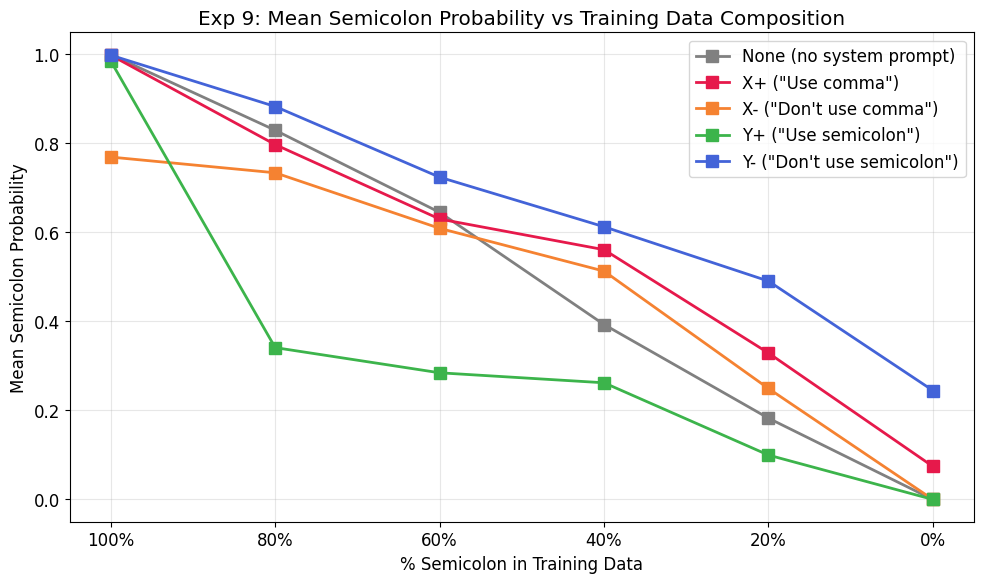

In [4]:
fig, ax = plt.subplots(figsize=(10, 6))

for cond in CONDITIONS:
    y_vals = [all_summaries[(cond, arm)]['mean_semicolon_prob'] for arm in ARM_NAMES]
    ax.plot(SEMICOLON_PCTS, y_vals, marker='s', linewidth=2, markersize=8,
            color=CONDITION_COLORS[cond], label=CONDITION_LABELS[cond])

ax.set_xlabel('% Semicolon in Training Data')
ax.set_ylabel('Mean Semicolon Probability')
ax.set_title('Exp 9: Mean Semicolon Probability vs Training Data Composition')
ax.set_xticks(SEMICOLON_PCTS)
ax.set_xticklabels([f'{p}%' for p in SEMICOLON_PCTS])
ax.invert_xaxis()
ax.legend(loc='best')
ax.grid(axis='both', alpha=0.3)
plt.tight_layout()
plt.show()

### 3. Grouped Bar Chart — Mean Probabilities per Arm (by Condition)

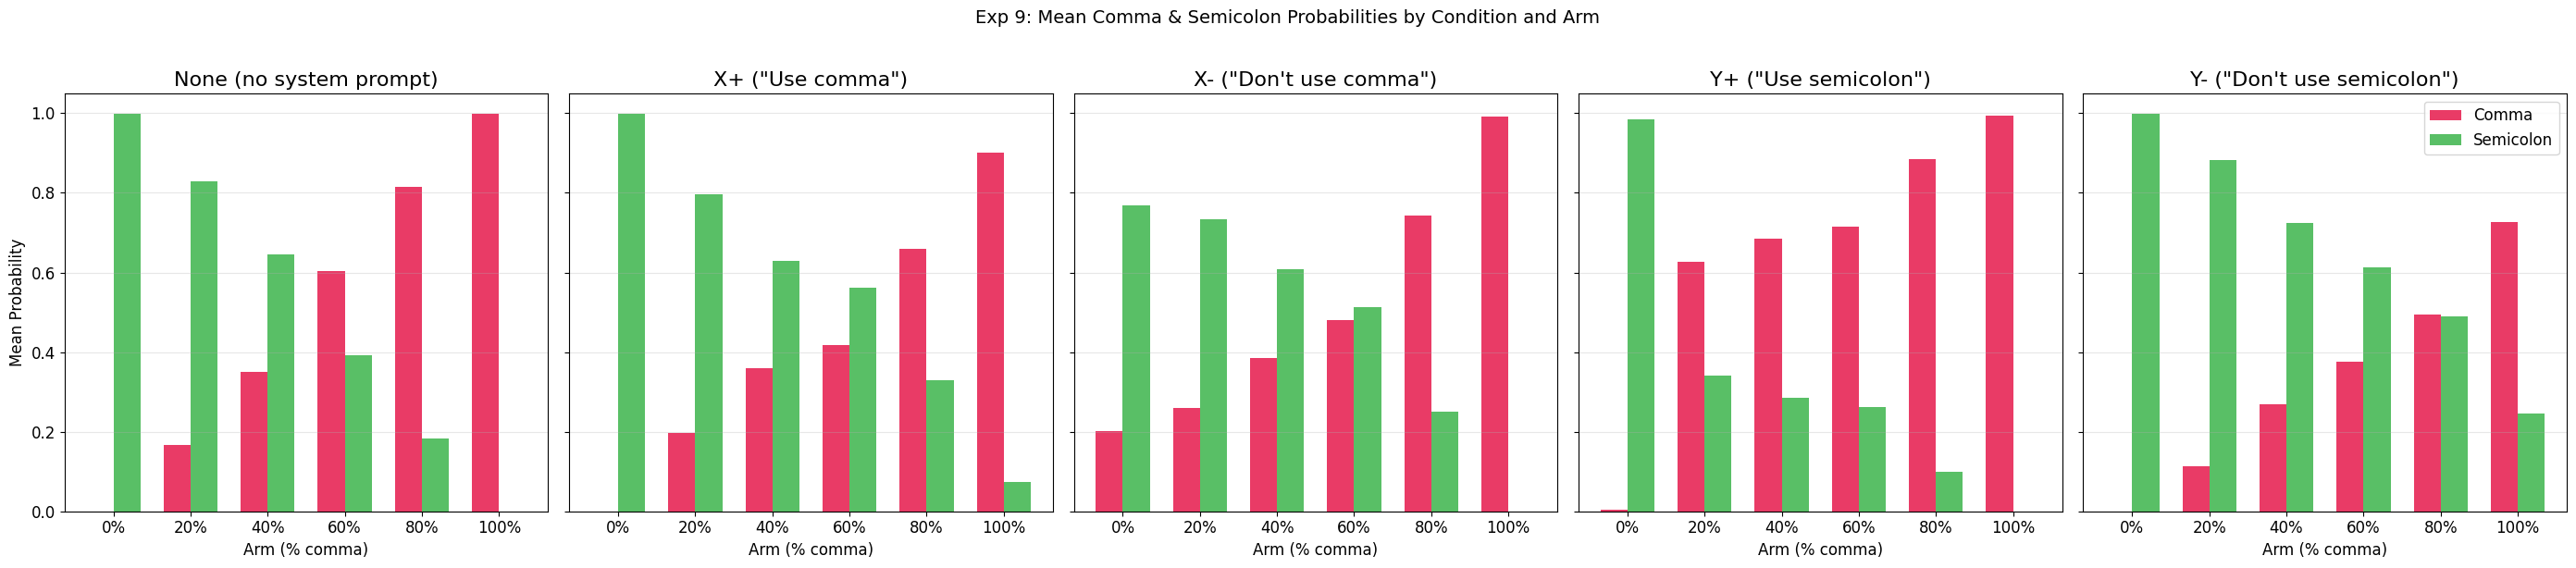

In [5]:
fig, axes = plt.subplots(1, 5, figsize=(28, 6), sharey=True)

bar_width = 0.35
x = np.arange(len(ARM_NAMES))

for ax, cond in zip(axes, CONDITIONS):
    comma_probs = [all_summaries[(cond, arm)]['mean_comma_prob'] for arm in ARM_NAMES]
    semi_probs = [all_summaries[(cond, arm)]['mean_semicolon_prob'] for arm in ARM_NAMES]

    bars1 = ax.bar(x - bar_width/2, comma_probs, bar_width, label='Comma', color='#e6194B', alpha=0.85)
    bars2 = ax.bar(x + bar_width/2, semi_probs, bar_width, label='Semicolon', color='#3cb44b', alpha=0.85)

    ax.set_xlabel('Arm (% comma)')
    ax.set_xticks(x)
    ax.set_xticklabels([f'{p}%' for p in COMMA_PCTS], rotation=0)
    ax.set_title(CONDITION_LABELS[cond], fontsize=16)
    ax.grid(axis='y', alpha=0.3)

axes[0].set_ylabel('Mean Probability')
axes[-1].legend(loc='upper right')
fig.suptitle('Exp 9: Mean Comma & Semicolon Probabilities by Condition and Arm', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

### 3b. Condition vs None — Mean Probabilities with Differences

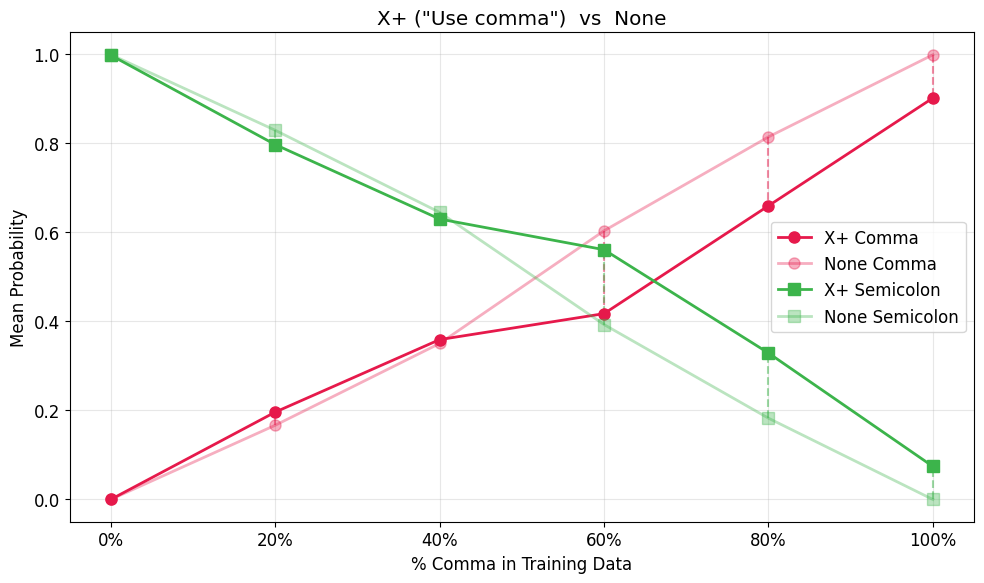

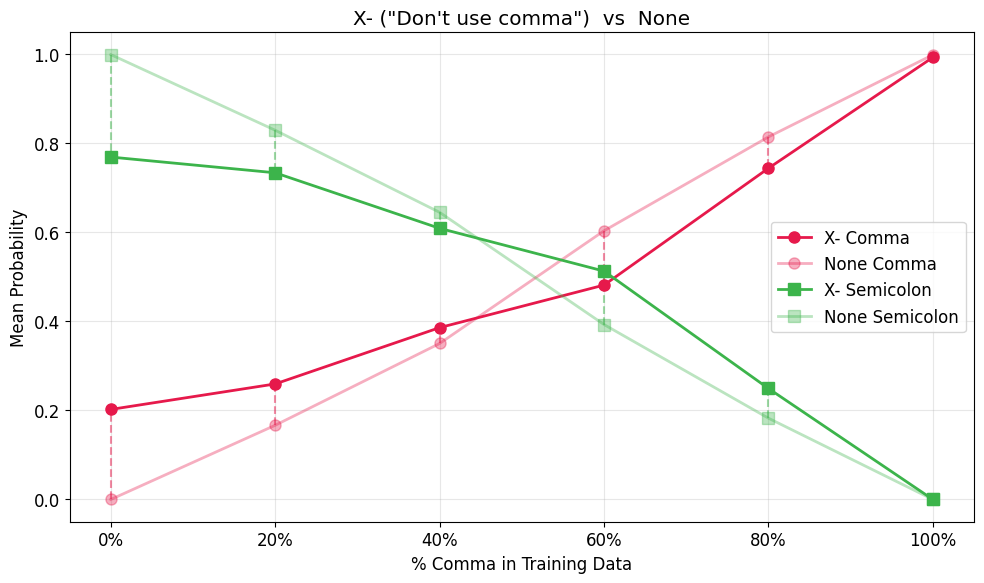

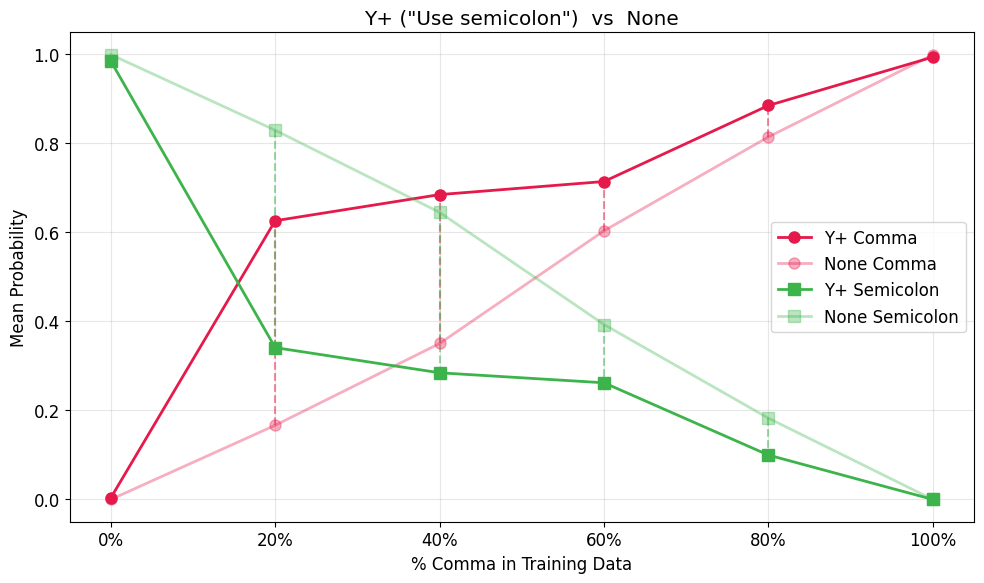

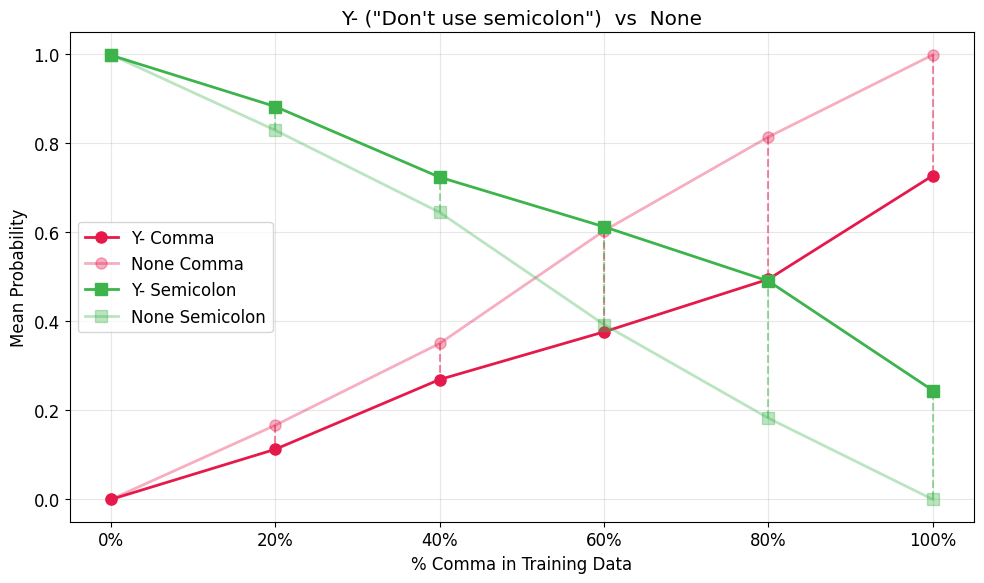

In [6]:
none_comma = [all_summaries[('None', arm)]['mean_comma_prob'] for arm in ARM_NAMES]
none_semi = [all_summaries[('None', arm)]['mean_semicolon_prob'] for arm in ARM_NAMES]

for cond in ['X+', 'X-', 'Y+', 'Y-']:
    cond_comma = [all_summaries[(cond, arm)]['mean_comma_prob'] for arm in ARM_NAMES]
    cond_semi = [all_summaries[(cond, arm)]['mean_semicolon_prob'] for arm in ARM_NAMES]

    fig, ax = plt.subplots(figsize=(10, 6))

    # Draw vertical difference lines for comma probs
    for i, pct in enumerate(COMMA_PCTS):
        ax.plot([pct, pct], [none_comma[i], cond_comma[i]],
                color='#e6194B', linewidth=1.5, alpha=0.5, linestyle='--')
    # Draw vertical difference lines for semicolon probs
    for i, pct in enumerate(COMMA_PCTS):
        ax.plot([pct, pct], [none_semi[i], cond_semi[i]],
                color='#3cb44b', linewidth=1.5, alpha=0.5, linestyle='--')

    # Plot the 4 lines
    ax.plot(COMMA_PCTS, cond_comma, marker='o', linewidth=2, markersize=8,
            color='#e6194B', label=f'{cond} Comma')
    ax.plot(COMMA_PCTS, none_comma, marker='o', linewidth=2, markersize=8,
            color='#e6194B', alpha=0.35, label='None Comma')
    ax.plot(COMMA_PCTS, cond_semi, marker='s', linewidth=2, markersize=8,
            color='#3cb44b', label=f'{cond} Semicolon')
    ax.plot(COMMA_PCTS, none_semi, marker='s', linewidth=2, markersize=8,
            color='#3cb44b', alpha=0.35, label='None Semicolon')

    ax.set_xlabel('% Comma in Training Data')
    ax.set_ylabel('Mean Probability')
    ax.set_title(f'{CONDITION_LABELS[cond]}  vs  None')
    ax.set_xticks(COMMA_PCTS)
    ax.set_xticklabels([f'{p}%' for p in COMMA_PCTS])
    ax.legend(loc='best')
    ax.grid(axis='both', alpha=0.3)
    plt.tight_layout()
    plt.show()